# Tuberculosis Detection from Chest X-Rays

Binary classification (Normal vs TB) using Vision Transformer (ViT) and Swin Transformer V2.

**Dataset:** [Tuberculosis Chest X-rays Images](https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tx-chest-xray-dataset)  
- Normal: 514 images  
- TB: 2494 images

In [1]:
import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.models import vit_b_16
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ========== CONFIGURATION ==========
# Set this to the root of the project (directory containing this notebook)
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))

# Path to the raw dataset folder
DATASET_DIR = os.path.join(PROJECT_ROOT, 'Dataset of Tuberculosis Chest X-rays Images')

# Path where the train/val/test split will be created
SPLIT_DIR = os.path.join(PROJECT_ROOT, 'TB_Binary_Split')

# Class names matching subfolder names
CLASS_MAP = {
    'NORMAL': os.path.join(DATASET_DIR, 'Normal Chest X-rays'),
    'TUBERCULOSIS': os.path.join(DATASET_DIR, 'TB Chest X-rays'),
}

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Dataset directory: {DATASET_DIR}')
print(f'Split directory: {SPLIT_DIR}')

KeyboardInterrupt: 

## 1. Prepare Train / Validation / Test Split (70:15:15)

In [ ]:
# Create train/val/test directories and copy images
train_dir = os.path.join(SPLIT_DIR, 'train')
val_dir   = os.path.join(SPLIT_DIR, 'val')
test_dir  = os.path.join(SPLIT_DIR, 'test')

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

for class_name, src_path in CLASS_MAP.items():
    if not os.path.exists(src_path):
        print(f'ERROR: Source path not found: {src_path}')
        continue

    images = [
        f for f in os.listdir(src_path)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    # rest goes to test

    splits = {
        'train': images[:n_train],
        'val':   images[n_train:n_train + n_val],
        'test':  images[n_train + n_val:],
    }

    for split_name, file_list in splits.items():
        dest = os.path.join(SPLIT_DIR, split_name, class_name)
        os.makedirs(dest, exist_ok=True)
        for fname in file_list:
            src_file = os.path.join(src_path, fname)
            dst_file = os.path.join(dest, fname)
            if not os.path.exists(dst_file):
                shutil.copy2(src_file, dst_file)

    print(f'{class_name}: total={n_total}, '
          f'train={len(splits["train"])}, '
          f'val={len(splits["val"])}, '
          f'test={len(splits["test"])}')

print('\nTrain/Val/Test split complete!')

NORMAL: total=514, train=359, val=77, test=78
TUBERCULOSIS: total=2494, train=1745, val=374, test=375

Train/Val/Test split complete!


## 2. Dataset Overview & Class Distribution


--- TRAIN ---
  NORMAL: 359
  TUBERCULOSIS: 1745

--- VAL ---
  NORMAL: 77
  TUBERCULOSIS: 374

--- TEST ---
  NORMAL: 78
  TUBERCULOSIS: 375


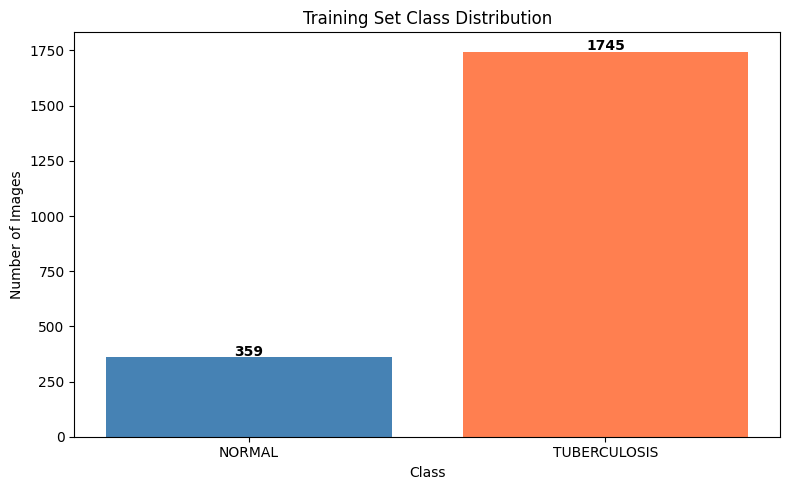

In [ ]:
# Count images per class per split
for split_name in ['train', 'val', 'test']:
    split_path = os.path.join(SPLIT_DIR, split_name)
    print(f'\n--- {split_name.upper()} ---')
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
            print(f'  {cls}: {count}')

# Bar chart of training distribution
train_path = os.path.join(SPLIT_DIR, 'train')
classes = sorted(os.listdir(train_path))
counts = []
for cls in classes:
    cls_path = os.path.join(train_path, cls)
    counts.append(len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]))

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['steelblue', 'coral'])
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for i, (cls, cnt) in enumerate(zip(classes, counts)):
    plt.text(i, cnt + 5, str(cnt), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model 1: Vision Transformer (ViT-B/16) — Full Fine-Tuning

In [ ]:
# ===================== Data Transforms =====================
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ===================== Load Datasets =====================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_test_transforms)

print(f'Classes: {train_dataset.classes}')
print(f'Class-to-index: {train_dataset.class_to_idx}')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

# ===================== Weighted Sampler (handle class imbalance) =====================
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1.0 / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(
    samples_weights, num_samples=len(samples_weights), replacement=True
)

# ===================== Data Loaders =====================
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

# ===================== Load & Modify ViT =====================
model = vit_b_16(weights='DEFAULT')
num_classes = len(train_dataset.classes)  # 2 classes
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
model = model.to(device)

# Unfreeze all layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# ===================== Loss, Optimizer, Scheduler =====================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ===================== Evaluate Function =====================
def evaluate(loader, calc_loss=False):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            if calc_loss:
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / total if calc_loss else None
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

# ===================== Training Loop =====================
num_epochs = 15
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

print(f'\nStarting ViT-B/16 training for {num_epochs} epochs...')
print(f'Number of classes: {num_classes}')
print(f'Batch size: {batch_size}\n')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects / total_train
    val_acc, val_loss, _, _ = evaluate(val_loader, calc_loss=True)
    test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, calc_loss=True)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}')

    scheduler.step()

# ===================== Final Evaluation =====================
print('\n===== ViT Final Results =====')
print(f'Train Accuracy: {train_accs[-1]:.4f} | Loss: {train_losses[-1]:.4f}')
print(f'Validation Accuracy: {val_accs[-1]:.4f} | Loss: {val_losses[-1]:.4f}')
print(f'Test Accuracy: {test_accs[-1]:.4f} | Loss: {test_losses[-1]:.4f}')

# ===================== Classification Report =====================
precision = precision_score(test_labels, test_preds, average='weighted')
recall = recall_score(test_labels, test_preds, average='weighted')
f1 = f1_score(test_labels, test_preds, average='weighted')
kappa = cohen_kappa_score(test_labels, test_preds)

print('\nClassification Report (Test Set):')
print(classification_report(test_labels, test_preds, target_names=test_dataset.classes))
print(f'Weighted Precision: {precision:.4f}')
print(f'Weighted Recall: {recall:.4f}')
print(f'Weighted F1 Score: {f1:.4f}')
print(f"Cohen's Kappa: {kappa:.4f}")

Classes: ['NORMAL', 'TUBERCULOSIS']
Class-to-index: {'NORMAL': 0, 'TUBERCULOSIS': 1}
Train: 2104, Val: 451, Test: 453

Starting ViT-B/16 training for 15 epochs...
Number of classes: 2
Batch size: 32

Epoch 1/15 | Train Loss: 0.0902 | Train Acc: 0.9667 | Val Loss: 0.0024 | Val Acc: 1.0000 | Test Loss: 0.0027 | Test Acc: 1.0000
Epoch 2/15 | Train Loss: 0.0015 | Train Acc: 1.0000 | Val Loss: 0.0017 | Val Acc: 1.0000 | Test Loss: 0.0009 | Test Acc: 1.0000
Epoch 3/15 | Train Loss: 0.0157 | Train Acc: 0.9957 | Val Loss: 0.0003 | Val Acc: 1.0000 | Test Loss: 0.0004 | Test Acc: 1.0000
Epoch 4/15 | Train Loss: 0.0044 | Train Acc: 0.9981 | Val Loss: 0.0002 | Val Acc: 1.0000 | Test Loss: 0.0004 | Test Acc: 1.0000
Epoch 5/15 | Train Loss: 0.0005 | Train Acc: 1.0000 | Val Loss: 0.0001 | Val Acc: 1.0000 | Test Loss: 0.0001 | Test Acc: 1.0000
Epoch 6/15 | Train Loss: 0.0049 | Train Acc: 0.9981 | Val Loss: 0.0001 | Val Acc: 1.0000 | Test Loss: 0.0002 | Test Acc: 1.0000
Epoch 7/15 | Train Loss: 0.0046 

## 4. ViT Training Curves & Confusion Matrix

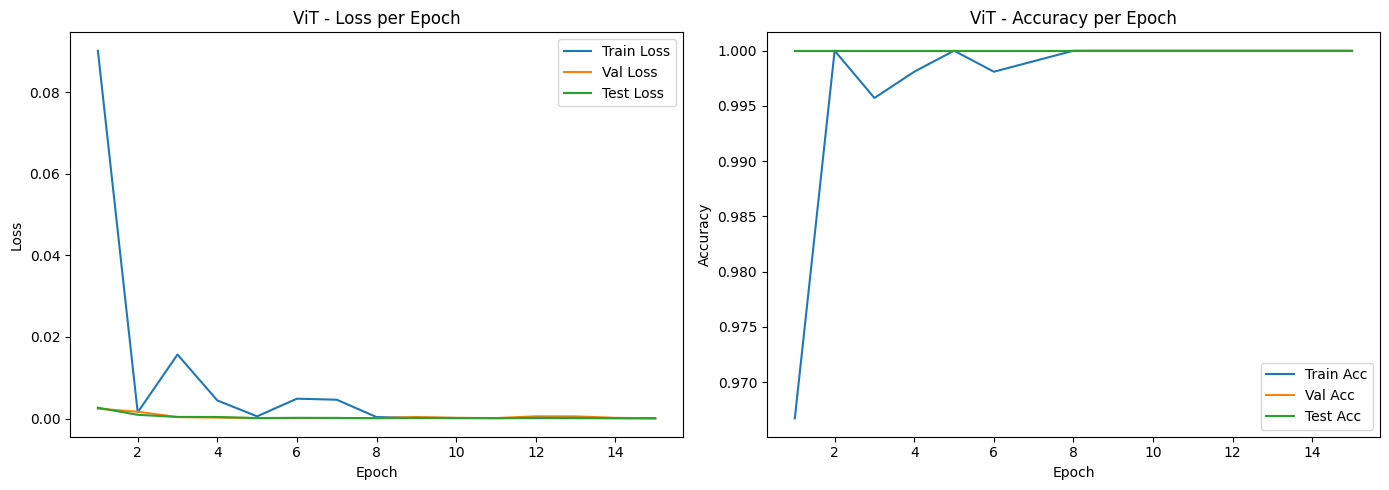

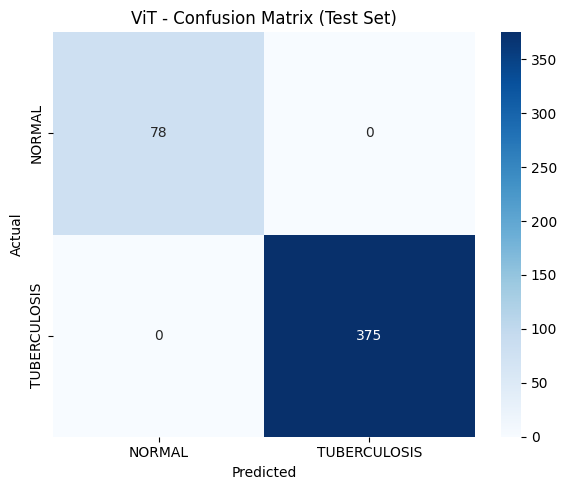

In [ ]:
# ===================== Plot Training Curves =====================
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_range, train_losses, label='Train Loss')
axes[0].plot(epochs_range, val_losses,   label='Val Loss')
axes[0].plot(epochs_range, test_losses,  label='Test Loss')
axes[0].set_title('ViT - Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curves
axes[1].plot(epochs_range, train_accs, label='Train Acc')
axes[1].plot(epochs_range, val_accs,   label='Val Acc')
axes[1].plot(epochs_range, test_accs,  label='Test Acc')
axes[1].set_title('ViT - Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# ===================== Confusion Matrix =====================
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title('ViT - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Model 2: Swin Transformer V2 Large

In [ ]:
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR

# ===================== Hyperparameters =====================
swin_batch_size = 16
swin_num_epochs = 25
swin_lr = 2e-4
swin_weight_decay = 1e-4

# ===================== Transforms (192x192 for SwinV2 Large) =====================
swin_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(192, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

swin_val_test_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===================== Datasets and Loaders =====================
swin_train_dataset = datasets.ImageFolder(train_dir, transform=swin_train_transform)
swin_val_dataset   = datasets.ImageFolder(val_dir,   transform=swin_val_test_transform)
swin_test_dataset  = datasets.ImageFolder(test_dir,  transform=swin_val_test_transform)

swin_train_loader = DataLoader(swin_train_dataset, batch_size=swin_batch_size,
                               shuffle=True, num_workers=2, pin_memory=True)
swin_val_loader   = DataLoader(swin_val_dataset,   batch_size=swin_batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)
swin_test_loader  = DataLoader(swin_test_dataset,  batch_size=swin_batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)

# ===================== SwinV2 Large Model =====================
swin_num_classes = len(swin_train_dataset.classes)
swin_model = timm.create_model(
    'swinv2_large_window12_192.ms_in22k',
    pretrained=True,
    num_classes=swin_num_classes
)
swin_model = swin_model.to(device)

# ===================== Loss, Optimizer, Scheduler =====================
swin_criterion = nn.CrossEntropyLoss()
swin_optimizer = optim.AdamW(swin_model.parameters(), lr=swin_lr, weight_decay=swin_weight_decay)
swin_scheduler = CosineAnnealingLR(swin_optimizer, T_max=swin_num_epochs)

# ===================== Evaluate =====================
def swin_evaluate(loader):
    swin_model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = swin_model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return correct / total, np.array(all_preds), np.array(all_labels)

# ===================== Training =====================
best_val_acc = 0.0
swin_train_acc_list, swin_val_acc_list, swin_test_acc_list = [], [], []
swin_train_loss_list = []

print(f'Starting SwinV2 Large training for {swin_num_epochs} epochs...\n')

for epoch in range(swin_num_epochs):
    swin_model.train()
    running_loss = 0
    for images, labels in tqdm(swin_train_loader, desc=f'Epoch {epoch+1}/{swin_num_epochs}'):
        images, labels = images.to(device), labels.to(device)

        swin_optimizer.zero_grad()
        outputs = swin_model(images)
        loss = swin_criterion(outputs, labels)
        loss.backward()
        swin_optimizer.step()

        running_loss += loss.item() * images.size(0)

    swin_scheduler.step()

    epoch_loss = running_loss / len(swin_train_dataset)
    train_acc, _, _ = swin_evaluate(swin_train_loader)
    val_acc,   _, _ = swin_evaluate(swin_val_loader)
    test_acc,  _, _ = swin_evaluate(swin_test_loader)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(swin_model.state_dict(), os.path.join(PROJECT_ROOT, 'best_swinv2_large.pth'))

    swin_train_loss_list.append(epoch_loss)
    swin_train_acc_list.append(train_acc)
    swin_val_acc_list.append(val_acc)
    swin_test_acc_list.append(test_acc)

    print(f'Epoch {epoch+1}/{swin_num_epochs} | Loss: {epoch_loss:.4f} | '
          f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

ModuleNotFoundError: No module named 'timm'

## 6. SwinV2 Training Curves & Final Evaluation

In [ ]:
# ===================== SwinV2 Training Curves =====================
swin_epochs_range = range(1, swin_num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(swin_epochs_range, swin_train_loss_list, label='Train Loss')
axes[0].set_title('SwinV2 - Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(swin_epochs_range, swin_train_acc_list, label='Train Acc')
axes[1].plot(swin_epochs_range, swin_val_acc_list,   label='Val Acc')
axes[1].plot(swin_epochs_range, swin_test_acc_list,  label='Test Acc')
axes[1].set_title('SwinV2 - Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# ===================== Load Best Model & Final Report =====================
best_path = os.path.join(PROJECT_ROOT, 'best_swinv2_large.pth')
if os.path.exists(best_path):
    swin_model.load_state_dict(torch.load(best_path, map_location=device))
    print('Loaded best SwinV2 model weights.\n')

final_test_acc, swin_test_preds, swin_test_labels = swin_evaluate(swin_test_loader)

print(f'SwinV2 Final Test Accuracy: {final_test_acc:.4f}')
print('\nClassification Report (Test Set):')
print(classification_report(swin_test_labels, swin_test_preds,
                            target_names=swin_test_dataset.classes))

swin_kappa = cohen_kappa_score(swin_test_labels, swin_test_preds)
print(f"Cohen's Kappa: {swin_kappa:.4f}")

# ===================== Confusion Matrix =====================
cm = confusion_matrix(swin_test_labels, swin_test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=swin_test_dataset.classes,
            yticklabels=swin_test_dataset.classes)
plt.title('SwinV2 - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()